**Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from google.colab import drive

**Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum11/data/earthquakes.csv"

In [ ]:
df = pd.read_csv(path)
df

,id,magnitude,type,title,date,time,updated,url,detailUrl,felt,...,location,continent,country,subnational,city,locality,postcode,what3words,timezone,locationDetails
0,us7000necw,4.8,earthquake,"M 4.8 - 33 km WSW of Ackerly, Texas",2024-09-17T00:49:42,1726534182289,1726583895255,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,1893,...,"Ackerly, Texas",North America,United States of America (the),Texas,Tarzan-Lenorah,Tarzan-Lenorah,79783.0,landmass.perkily.affords,-300,"[{'id': '80684', 'wikidataId': '', 'name': '79..."
1,tx2024shcj,5.1,earthquake,"M 5.1 - 34 km WSW of Ackerly, Texas",2024-09-17T00:49:42,1726534182183,1726672002991,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2042,...,"Ackerly, Texas",North America,United States of America (the),Texas,Tarzan-Lenorah,Tarzan-Lenorah,79331.0,escalator.grownups.dwell,-300,"[{'id': '89341', 'wikidataId': '', 'name': '48..."
2,ci40734823,3.7,earthquake,"M 3.7 - 6 km N of Malibu, CA",2024-09-16T11:22:08,1726485728190,1726637414586,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,1580,...,"Malibu, CA",North America,United States of America (the),California,Los Angeles,Agoura Hills-Malibu,90265.0,clocking.uploaded.issuer,-420,"[{'id': '93478', 'wikidataId': 'Q844837', 'nam..."
3,tx2024scvz,3.9,earthquake,"M 3.9 - 58 km S of Whites City, New Mexico",2024-09-14T17:01:06,1726333266539,1726584426218,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,5,...,"Whites City, New Mexico",North America,United States of America (the),Texas,Van Horn,Van Horn,NaN,sailboats.sawn.speeding,-300,"[{'id': '9', 'wikidataId': 'Q49', 'name': 'Nor..."
4,us7000ndte,4.1,earthquake,"M 4.1 - 60 km S of Whites City, New Mexico",2024-09-14T17:01:06,1726333266382,1726334616179,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,4,...,"Whites City, New Mexico",North America,United States of America (the),Texas,Van Horn,Van Horn,NaN,spinners.downtime.computes,-300,"[{'id': '9', 'wikidataId': 'Q49', 'name': 'Nor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132,us6000ldpm,6.3,earthquake,"M 6.3 - 25 km NNE of Zindah Jān, Afghanistan",2023-10-07T07:12:49,1696662769702,1702589215040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,11,...,"Zindah Jān, Afghanistan",Asia,Afghanistan,Herat,Zindah Jan,Zendeh Jan District,NaN,staked.radish.enduringly,270,"[{'id': '108', 'wikidataId': 'Q48', 'name': 'A..."
1133,us6000ldph,5.4,earthquake,"M 5.4 - 26 km NE of Zindah Jān, Afghanistan",2023-10-07T06:49:41,1696661381156,1702589215040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,0,...,"Zindah Jān, Afghanistan",Asia,Afghanistan,Herat,Zindah Jan,Zendeh Jan District,NaN,bloomers.wondrous.possibility,270,"[{'id': '108', 'wikidataId': 'Q48', 'name': 'A..."
1134,us6000ldpg,6.3,earthquake,"M 6.3 - 32 km NNE of Zindah Jān, Afghanistan",2023-10-07T06:41:03,1696660863327,1702589215040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,19,...,"Zindah Jān, Afghanistan",Asia,Afghanistan,Herat,Zindah Jan,Zendeh Jan District,NaN,outshone.freedmen.inequality,270,"[{'id': '108', 'wikidataId': 'Q48', 'name': 'A..."
1135,us6000lcgj,5.7,earthquake,"M 5.7 - 39 km NE of Dipayal, Nepal",2023-10-03T09:21:03,1696324863018,1702589211040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,131,...,"Dipayal, Nepal",Asia,Nepal,Sudurpashchim,Jayaprithivi,JayaPrithvi-03,NaN,investments.ticketholder.hopefulness,345,"[{'id': '87376', 'wikidataId': '', 'name': 'As..."


In [ ]:
print(f"Data berhasil dimuat. Total baris: {df.shape[0]}")
print("\n5 Data Pertama:")
print(df[['latitude', 'longitude']].head())

Data berhasil dimuat. Total baris: 1137

5 Data Pertama:
   latitude  longitude
0   32.3984   -102.044
1   32.4140   -102.057
2   34.0678   -118.807
3   31.6470   -104.450
4   31.6323   -104.473


In [ ]:
# 1. Pemilihan Fitur
# Fokus pada fitur geospasial: latitude dan longitude
df_gps = df[['latitude', 'longitude']].copy()

In [ ]:
# 2. Cleaning Data
# Cek dan hapus Missing Value & Duplikasi
df_gps.drop_duplicates(inplace=True)
df_gps.dropna(inplace=True)

print("--- Informasi Data Setelah Cleaning ---")
print(f"Total titik data (gempa) yang akan diproses: {df_gps.shape[0]}")

--- Informasi Data Setelah Cleaning ---
Total titik data (gempa) yang akan diproses: 602


In [ ]:
# 3. Konversi ke Radian (Normalization untuk Haversine Metric)
# Wajib dilakukan untuk menghitung jarak di permukaan bumi
coords_rad = np.radians(df_gps[['latitude', 'longitude']].to_numpy())

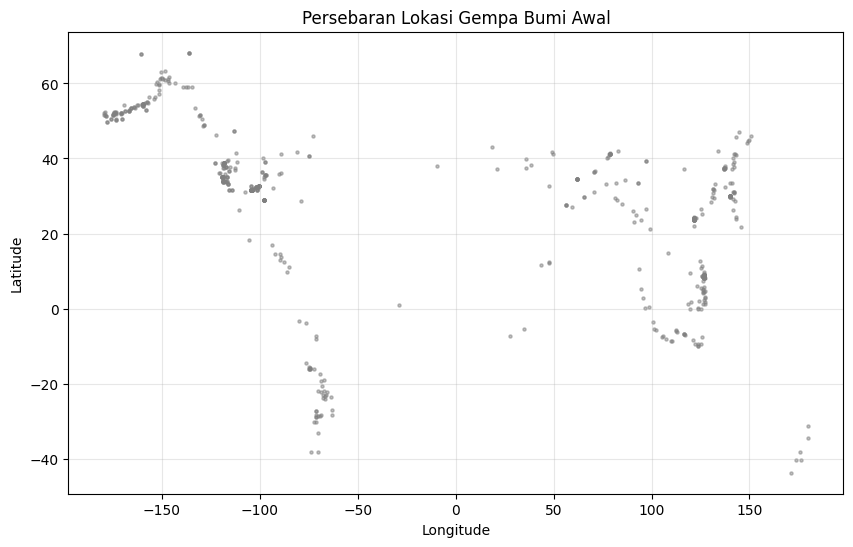

In [ ]:
# Visualisasi Awal Persebaran Gempa (EDA)
plt.figure(figsize=(10, 6))
plt.scatter(df_gps['longitude'], df_gps['latitude'], s=5, alpha=0.5, c='grey')
plt.title("Persebaran Lokasi Gempa Bumi Awal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.show()

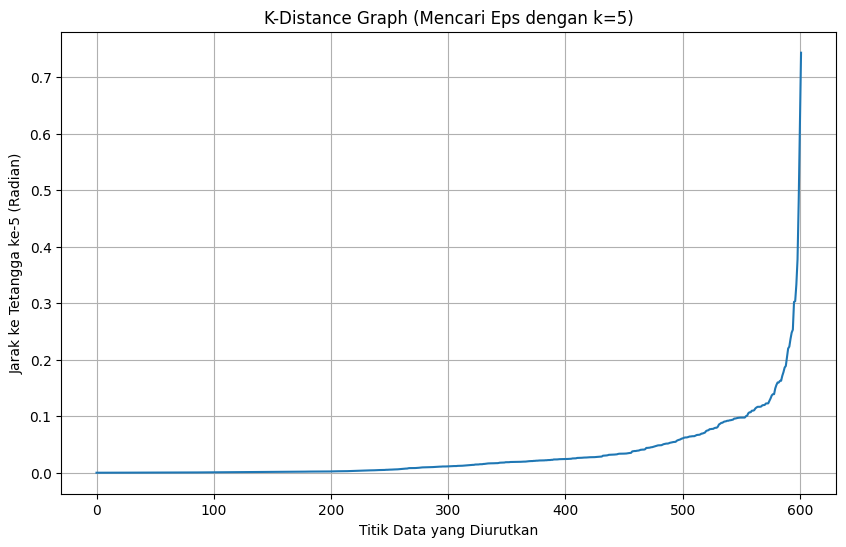


ANALISIS GRAFIK:
Nilai y pada titik siku (elbow) adalah kandidat terbaik untuk parameter 'eps' (dalam radian).


In [ ]:
# Penentuan nilai eps: Mencari titik siku (elbow) pada grafik
# Kita gunakan k = min_samples - 1. Misal kita set min_samples = 5, maka k=4.
k = 4
nbrs = NearestNeighbors(n_neighbors=k, metric='haversine').fit(coords_rad)
distances, indices = nbrs.kneighbors(coords_rad)

# Urutkan jarak ke tetangga ke-k dan plot
distance_desc = sorted(distances[:, k-1], reverse=False)

plt.figure(figsize=(10, 6))
plt.plot(distance_desc)
plt.title(f"K-Distance Graph (Mencari Eps dengan k={k+1})")
plt.ylabel("Jarak ke Tetangga ke-5 (Radian)")
plt.xlabel("Titik Data yang Diurutkan")
plt.grid(True)
plt.show()

print("\nANALISIS GRAFIK:")
print("Nilai y pada titik siku (elbow) adalah kandidat terbaik untuk parameter 'eps' (dalam radian).")

In [ ]:
# 1. Tentukan Parameter Berdasarkan Analisis (Sesuaikan eps_km Anda)
kms_per_radian = 6371.0088
eps_km = 100 # <--- UBAH/TENTUKAN NILAI INI BERDASARKAN GRAFIK DI SEL 4!
eps_rad = eps_km / kms_per_radian
min_samples = 5

In [ ]:
# 2. Jalankan DBSCAN
db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine', algorithm='ball_tree')
db.fit(coords_rad)

# Simpan label hasil clustering
df_gps['Cluster'] = db.labels_

# Hitung statistik hasil
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)

print(f"--- HASIL CLUSTERING ---")
print(f"Parameter Digunakan: eps={eps_km} km, min_samples={min_samples}")
print(f"Jumlah Cluster Terbentuk: {n_clusters}")
print(f"Jumlah Noise (Gempa Terpencil): {n_noise}")

--- HASIL CLUSTERING ---
Parameter Digunakan: eps=100 km, min_samples=5
Jumlah Cluster Terbentuk: 21
Jumlah Noise (Gempa Terpencil): 276


In [ ]:
# 3. Evaluasi dengan Silhouette Score
if n_clusters > 1 and n_clusters < len(df_gps):
    # Hitung Silhouette Score hanya jika ada lebih dari 1 cluster valid
    sil_score = silhouette_score(coords_rad, db.labels_)
    print(f"Silhouette Score: {sil_score:.4f}")
    print("\nInterpretasi: Nilai positif mendekati 1 menunjukkan cluster terpisah dengan baik.")
else:
    print("Silhouette Score tidak dapat dihitung (terlalu sedikit cluster valid).")

Silhouette Score: 0.0433

Interpretasi: Nilai positif mendekati 1 menunjukkan cluster terpisah dengan baik.


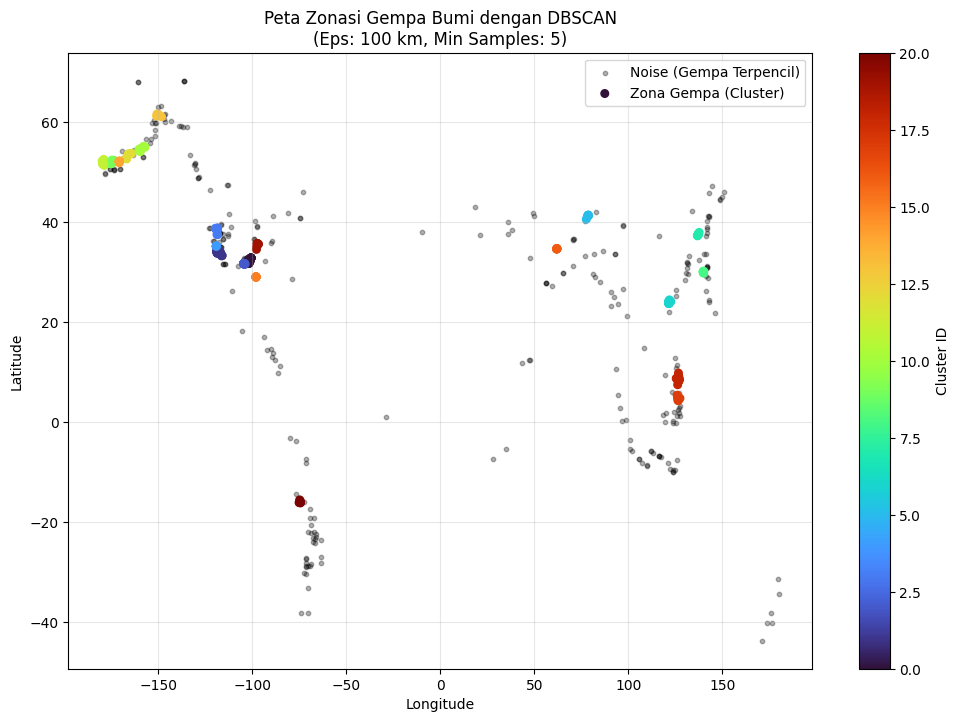

In [ ]:
# Visualisasi Akhir Persebaran Cluster dan Noise
plt.figure(figsize=(12, 8))

# Filter Data
noise_data = df_gps[df_gps['Cluster'] == -1]
cluster_data = df_gps[df_gps['Cluster'] != -1]

# 1. Plot Noise (Titik hitam untuk gempa terpencil)
plt.scatter(noise_data['longitude'], noise_data['latitude'],
            s=10, c='black', label='Noise (Gempa Terpencil)', alpha=0.3)

# 2. Plot Cluster (Zona Gempa Aktif)
scatter = plt.scatter(cluster_data['longitude'], cluster_data['latitude'],
            c=cluster_data['Cluster'], cmap='turbo', s=30, label='Zona Gempa (Cluster)')

plt.title(f"Peta Zonasi Gempa Bumi dengan DBSCAN\n(Eps: {eps_km} km, Min Samples: {min_samples})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Cluster ID')
plt.show()